In [34]:
#!/usr/bin/env python3

import rosbag
import matplotlib.pyplot as plt
import numpy as np

bag_file = 'dados_copilot_fail.bag'
bag = rosbag.Bag(bag_file)

# --- Pose (position only) ---
pose_times, pose_x, pose_y, pose_z = [], [], [], []

# --- Angular data ---
ang_times, ang_x, ang_y, ang_z = [], [], [], []
ang_rate_times, ang_rate_x, ang_rate_y, ang_rate_z = [], [], [], []

# --- Battery ---
batt_level = []
batt_volt = []

# --- Can fly & is flying ---
can_fly = []
is_flying = []

# --- Velocity ---
vel_times, vel_x, vel_y, vel_z = [], [], [], []

# --- Z range ---
zrange_times, zrange_x, zrange_y, zrange_z = [], [], [], []

# --- Copilot cmd_vel ---
cmd_vel_lin_x, cmd_vel_lin_y, cmd_vel_lin_z = [], [], []
cmd_vel_ang_x, cmd_vel_ang_y, cmd_vel_ang_z = [], [], []

for topic, msg, t in bag.read_messages():
    if topic == '/vrpn_client_node/cf1/pose':
        pose_times.append(msg.header.stamp.to_sec())
        pose_x.append(msg.pose.position.x)
        pose_y.append(msg.pose.position.y)
        pose_z.append(msg.pose.position.z)

    elif topic == '/cf1/crazyflieAng':
        ang_times.append(msg.header.stamp.to_sec())
        ang_x.append(msg.vector.x)
        ang_y.append(msg.vector.y)
        ang_z.append(msg.vector.z)

    elif topic == '/cf1/crazyflieAngRate':
        ang_rate_times.append(msg.header.stamp.to_sec())
        ang_rate_x.append(msg.vector.x)
        ang_rate_y.append(msg.vector.y)
        ang_rate_z.append(msg.vector.z)

    elif topic == '/cf1/crazyflieBatteryLevel':
        batt_level.append(msg.data)

    elif topic == '/cf1/crazyflieBatteryVoltage':
        batt_volt.append(msg.data)

    elif topic == '/cf1/crazyflieCanFly':
        can_fly.append(msg.data)

    elif topic == '/cf1/crazyflieIsFlying':
        is_flying.append(msg.data)

    elif topic == '/cf1/crazyflieVel':
        vel_times.append(msg.header.stamp.to_sec())
        vel_x.append(msg.vector.x)
        vel_y.append(msg.vector.y)
        vel_z.append(msg.vector.z)

    elif topic == '/cf1/crazyflieZRange':
        zrange_times.append(msg.header.stamp.to_sec())
        zrange_x.append(msg.vector.x)
        zrange_y.append(msg.vector.y)
        zrange_z.append(msg.vector.z)

    elif topic == '/cf1/copilot_cmd_vel':
        cmd_vel_lin_x.append(msg.linear.x)
        cmd_vel_lin_y.append(msg.linear.y)
        cmd_vel_lin_z.append(msg.linear.z)
        cmd_vel_ang_x.append(msg.angular.x)
        cmd_vel_ang_y.append(msg.angular.y)
        cmd_vel_ang_z.append(msg.angular.z)

bag.close()

pose_times = np.array(pose_times)
pose_x = np.array(pose_x)
pose_y = np.array(pose_y)
pose_z = np.array(pose_z)
ang_times = np.array(ang_times)
ang_x = np.array(ang_x)
ang_y = np.array(ang_y)
ang_z = np.array(ang_z)
ang_rate_times = np.array(ang_rate_times)
ang_rate_x = np.array(ang_rate_x)
ang_rate_y = np.array(ang_rate_y)
ang_rate_z = np.array(ang_rate_z)
batt_level = np.array(batt_level)
batt_volt = np.array(batt_volt)
can_fly = np.array(can_fly)
is_flying = np.array(is_flying)
vel_times = np.array(vel_times)
vel_x = np.array(vel_x)
vel_y = np.array(vel_y)
vel_z = np.array(vel_z)
zrange_times = np.array(zrange_times)
zrange_x = np.array(zrange_x)
zrange_y = np.array(zrange_y)
zrange_z = np.array(zrange_z)
cmd_vel_lin_x = np.array(cmd_vel_lin_x)
cmd_vel_lin_y = np.array(cmd_vel_lin_y)
cmd_vel_lin_z = np.array(cmd_vel_lin_z)
cmd_vel_ang_x = np.array(cmd_vel_ang_x)
cmd_vel_ang_y = np.array(cmd_vel_ang_y)
cmd_vel_ang_z = np.array(cmd_vel_ang_z)


pose_times = pose_times - pose_times[0]
ang_times = ang_times - ang_times[0]
ang_rate_times = ang_rate_times - ang_rate_times[0]
vel_times = vel_times - vel_times[0]
zrange_times = zrange_times - zrange_times[0]

print("Leitura finalizada!")

Leitura finalizada!


/tmp/ipykernel_31921/799918022.py:7: RuntimeWarning: invalid value encountered in divide
  vrpn_vel_x = vrpn_vel_x / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])
/tmp/ipykernel_31921/799918022.py:8: RuntimeWarning: invalid value encountered in divide
  vrpn_vel_y = vrpn_vel_y / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])
/tmp/ipykernel_31921/799918022.py:9: RuntimeWarning: invalid value encountered in divide
  vrpn_vel_z = vrpn_vel_z / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])


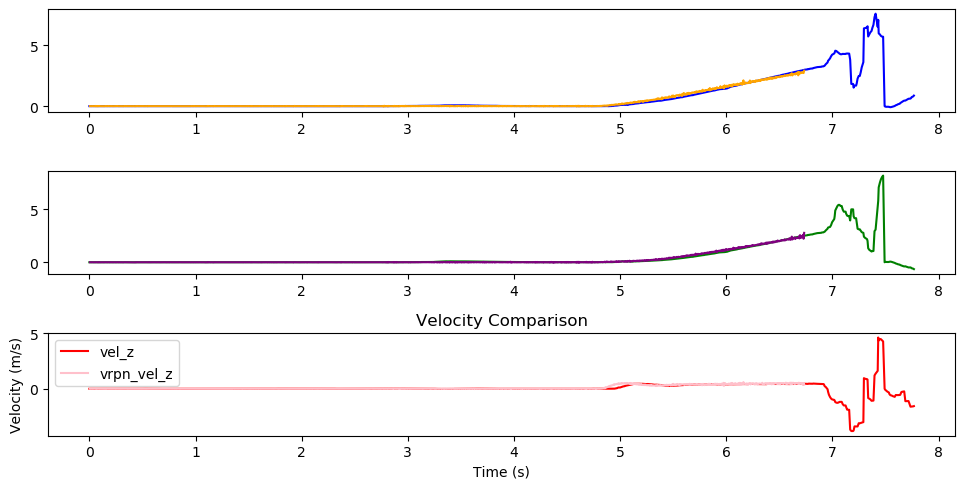

In [35]:
# plot crazyflievel and vrpn velocity

vrpn_vel_times = np.array(pose_times)
vrpn_vel_x = np.diff(pose_x, prepend=pose_x[0])  # Velocidade em x
vrpn_vel_y = np.diff(pose_y, prepend=pose_y[0])  # Velocidade em y
vrpn_vel_z = np.diff(pose_z, prepend=pose_z[0])  # Velocidade em z
vrpn_vel_x = vrpn_vel_x / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])
vrpn_vel_y = vrpn_vel_y / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])
vrpn_vel_z = vrpn_vel_z / np.diff(vrpn_vel_times, prepend=vrpn_vel_times[0])
# plot crazyflievel and vrpn velocity


plt.figure(figsize=(10, 5))
plt.subplot(3, 1, 1)

plt.plot(vel_times, vel_x, label='vel_x', color='blue')
plt.plot(vrpn_vel_times, vrpn_vel_x, label='vrpn_vel_x', color='orange')

plt.subplot(3, 1, 2)
plt.plot(vel_times, vel_y, label='vel_y', color='green')
plt.plot(vrpn_vel_times, vrpn_vel_y, label='vrpn_vel_y', color='purple')

plt.subplot(3, 1, 3)
plt.plot(vel_times, vel_z, label='vel_z', color='red')
plt.plot(vrpn_vel_times, vrpn_vel_z, label='vrpn_vel_z', color='pink')

plt.xlabel('Time (s)')

plt.ylabel('Velocity (m/s)')
plt.title('Velocity Comparison')
plt.legend()
plt.tight_layout()
plt.show()

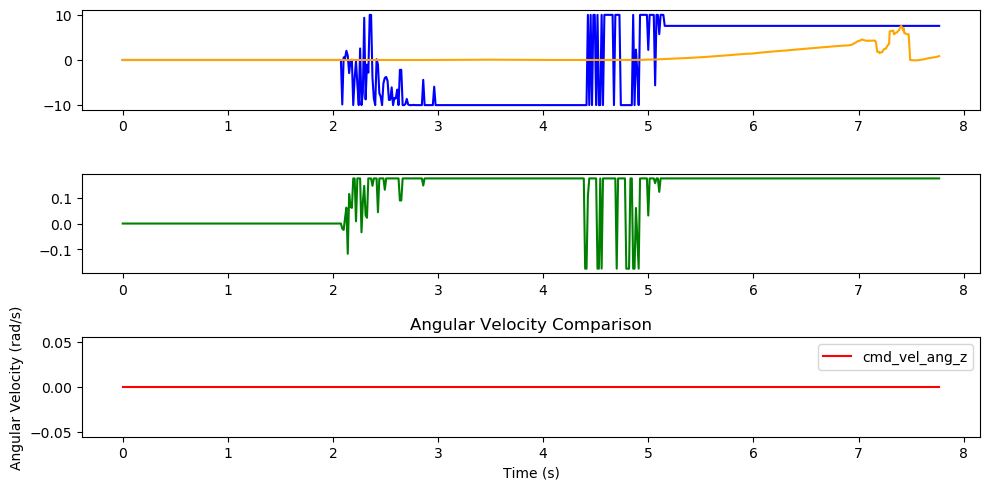

In [ ]:
# plot cmd vel angular

plt.figure(figsize=(10, 5))
cmd_vel_time = np.linspace(0, vel_times[-1] - vel_times[0], len(cmd_vel_ang_x))
plt.subplot(3, 1, 1)
plt.plot(cmd_vel_time, np.rad2deg(cmd_vel_ang_x), label='cmd_vel_ang_x', color='blue')
plt.plot(vel_times, vel_x, label='vel_x', color='orange')
plt.subplot(3, 1, 2)
plt.plot(cmd_vel_time, cmd_vel_ang_y, label='cmd_vel_ang_y', color='green')
plt.plot(ang_rate_times, ang_rate_y, label='ang_rate_y', color='purple')
plt.subplot(3, 1, 3)
plt.plot(cmd_vel_time, cmd_vel_ang_z, label='cmd_vel_ang_z', color='red')
# plt.plot(ang_rate_times, ang_rate_z, label='ang_rate_z', color='pink')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.title('Angular Velocity Comparison')
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
cmd_vel_time

array([0.        , 0.0130539 , 0.0261078 , 0.0391617 , 0.0522156 ,
       0.0652695 , 0.0783234 , 0.09137729, 0.10443119, 0.11748509,
       0.13053899, 0.14359289, 0.15664679, 0.16970069, 0.18275459,
       0.19580849, 0.20886239, 0.22191629, 0.23497019, 0.24802409,
       0.26107799, 0.27413188, 0.28718578, 0.30023968, 0.31329358,
       0.32634748, 0.33940138, 0.35245528, 0.36550918, 0.37856308,
       0.39161698, 0.40467088, 0.41772478, 0.43077868, 0.44383257,
       0.45688647, 0.46994037, 0.48299427, 0.49604817, 0.50910207,
       0.52215597, 0.53520987, 0.54826377, 0.56131767, 0.57437157,
       0.58742547, 0.60047937, 0.61353326, 0.62658716, 0.63964106,
       0.65269496, 0.66574886, 0.67880276, 0.69185666, 0.70491056,
       0.71796446, 0.73101836, 0.74407226, 0.75712616, 0.77018006,
       0.78323396, 0.79628785, 0.80934175, 0.82239565, 0.83544955,
       0.84850345, 0.86155735, 0.87461125, 0.88766515, 0.90071905,
       0.91377295, 0.92682685, 0.93988075, 0.95293465, 0.96598

In [20]:
len(cmd_vel_ang_x)

596

In [18]:
cmd_vel_times

[]

In [24]:
vel_times[-1] - vel_times[0]

7.767070055007935

In [22]:
596/7.76

76.80412371134021

array([0.        , 0.01305882, 0.02611765, 0.03917647, 0.05223529,
       0.06529412, 0.07835294, 0.09141176, 0.10447059, 0.11752941,
       0.13058824, 0.14364706, 0.15670588, 0.16976471, 0.18282353,
       0.19588235, 0.20894118, 0.222     , 0.23505882, 0.24811765,
       0.26117647, 0.27423529, 0.28729412, 0.30035294, 0.31341176,
       0.32647059, 0.33952941, 0.35258824, 0.36564706, 0.37870588,
       0.39176471, 0.40482353, 0.41788235, 0.43094118, 0.444     ,
       0.45705882, 0.47011765, 0.48317647, 0.49623529, 0.50929412,
       0.52235294, 0.53541176, 0.54847059, 0.56152941, 0.57458824,
       0.58764706, 0.60070588, 0.61376471, 0.62682353, 0.63988235,
       0.65294118, 0.666     , 0.67905882, 0.69211765, 0.70517647,
       0.71823529, 0.73129412, 0.74435294, 0.75741176, 0.77047059,
       0.78352941, 0.79658824, 0.80964706, 0.82270588, 0.83576471,
       0.84882353, 0.86188235, 0.87494118, 0.888     , 0.90105882,
       0.91411765, 0.92717647, 0.94023529, 0.95329412, 0.96635